In [13]:
import os
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import scipy 

from dekef.scorematching_penalized_grid_points import *

import seaborn as sns
from IPython.display import Markdown as md

from matplotlib import ticker, cm
from dekef.plot_density_1d import *

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.patches import Ellipse

In [2]:
os.chdir('../')

df = np.load('data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
waiting = waiting[waiting != 108.0]

In [3]:
info_coord = (0.03, 0.8)
info_coord1 = (0.03, 0.97)
info_coord2 = (0.03, 0.87)

In [4]:
label_fontsize = 25
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 30
linewidth = 4.0

In [10]:
contam_data_list =  np.arange(20, 152, 2) 
log_pen_list = np.arange(-12., -0.5, 0.5)
bw = 5.0
kernel_type = 'gaussian_poly2'

# file_name = f'data/data=waiting-bw={bw}-kernel={kernel_type}-empirical-inf-fun-summary-baseden=Gamma-26-3-gridpoints=1-181-1.xlsx'
file_name = f'data/data=waiting-bw={bw}-kernel={kernel_type}-contamweight=0.001-summary-baseden=Gamma-26-3-gridpoints=1-231-1.xlsx'

summary_df_ml = pd.read_excel(file_name, f'ML-result')
# summary_df_sm = pd.read_excel(file_name, f'SM-result')
summary_df_sm = pd.read_excel(file_name, f'Sheet1')

grid_points = np.arange(1., 181., 1).reshape(-1, 1)


## log density estimates and influence function

In [ ]:
# savef = '/Users/chenxizhou/Dropbox/code_package/IFlogdensity/'
# ml_folder = (savef + f'data/data=geyser-waiting-PenML-bw={bw}-kernel=gaussian_poly2-empirical-inf-fun-' + 
#              f'plotdomain=(1.0, 210.0)-plotcnts=3000-seed=1-baseden=gamma-26.0-3.0-grid_points=1-181-1')

# sm_folder = (savef + f'data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel=gaussian_poly2-empirical-inf-fun-' + 
#              f'plotdomain=(1.0, 210.0)-plotcnts=3000-baseden=26.0-3.0-grid_points=1-181-1')

In [6]:
from dekef.base_density import *
xlimit = (1., 210.)
plot_pts_cnt = 3000
base_density = BasedenUniform(waiting, [[1e-10, 210.]]) # BasedenGamma(waiting, 26., 3.)
new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)
base_den_vals = base_density.baseden_eval(new_data.reshape(-1, 1))

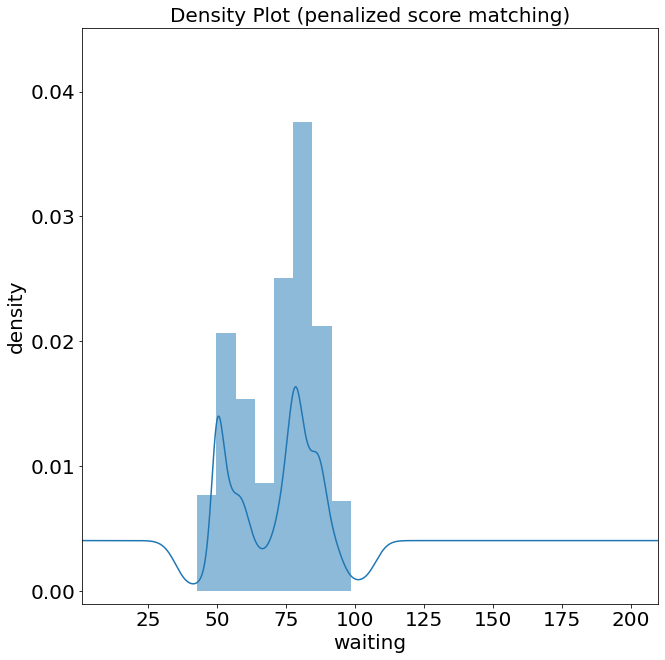

In [17]:
sm_logpen = -8.
ylimit = (-0.001, 0.0451)
plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)

sm_pen = ScoreMatchingPenalizedGridPoints(
    data = waiting, 
    grid_points = grid_points,
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw)

coef_smpen = sm_pen.coef(
    data = waiting, 
    lambda_param = np.exp(sm_logpen))

den_vals1 = plot_density_1d(
        data = waiting.reshape(-1, 1), 
        kernel_function = sm_pen.kernel_function_gridpoints, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = coef_smpen, 
        normalizing = True, 
        method = 'penalized score matching', 
        x_label = 'waiting',
        grid_points = grid_points,
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)

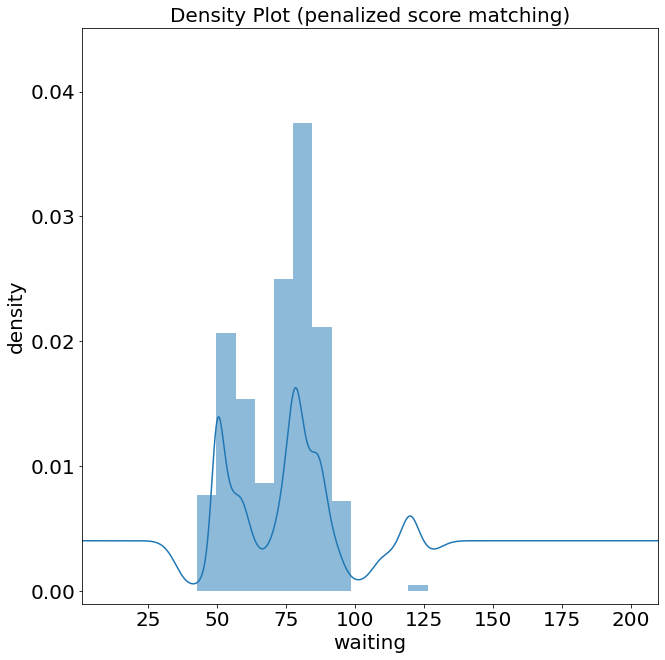

In [24]:
new_waiting = np.append(waiting.flatten(), 120.).reshape(-1, 1)

sm_pen = ScoreMatchingPenalizedGridPoints(
    data = new_waiting, 
    grid_points = grid_points,
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw)

coef_smpen = sm_pen.coef(
    data = new_waiting, 
    lambda_param = np.exp(sm_logpen))

den_vals2 = plot_density_1d(
        data = new_waiting, 
        kernel_function = sm_pen.kernel_function_gridpoints, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = coef_smpen, 
        normalizing = True, 
        method = 'penalized score matching', 
        x_label = 'waiting',
        grid_points = grid_points,
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)

0.39573924791803705


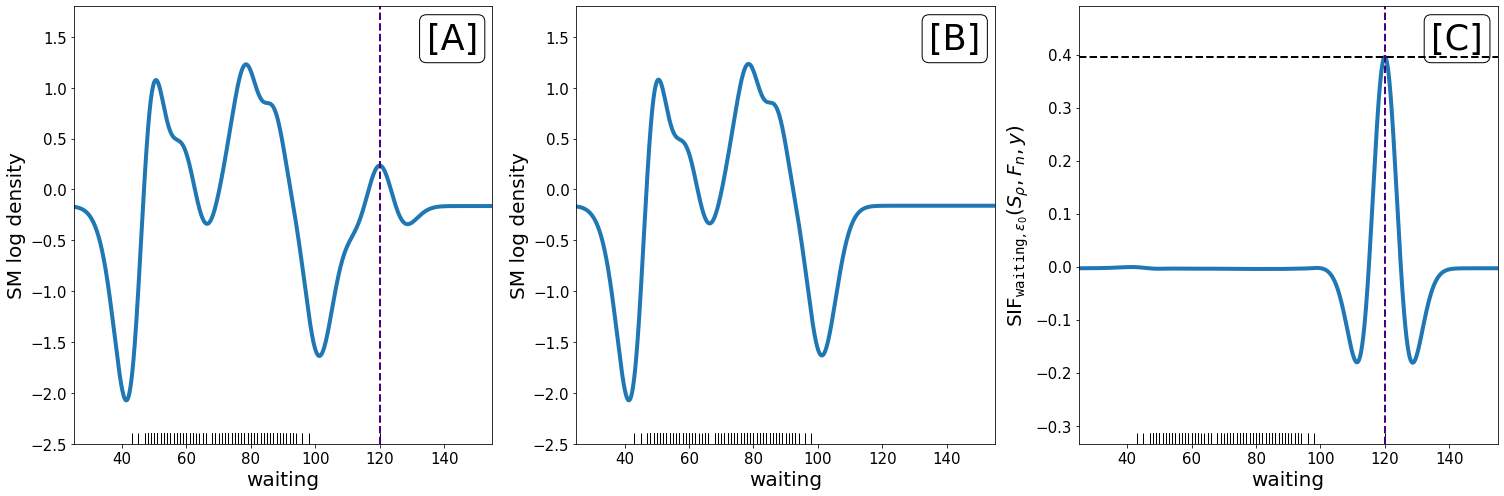

In [28]:
den_plot_xlim = (25., 155.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim
logden_plot_ylim = (-2.5, 1.8)

contam_weight = 1. / (len(waiting) + 1)

contam_data = 120.0

info_coord = (0.965, 0.965)
horizontalalignment, verticalalignment = 'right', 'top'

label_fontsize = 20
info_fontsize = 35
tick_fontsize = 15
legend_fontsize = 25
linewidth = 4.0
x_label = r'waiting'
y_label = r'log density'

nrows = 1
ncols = 3

fig = plt.figure(figsize=(21, 7))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120, 140]

color = 'tab:blue'

# ----------------------------------------------------------------------------------------
i = 0
ax1 = fig.add_subplot(gs[i, 0])
        
ax1.plot(new_data.flatten(), np.log(den_vals2['den_vals']).flatten() - np.log(base_den_vals.flatten()), 
         linewidth = linewidth, color = color)

sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')

ax1.axvline(contam_data, 0, 1, ls = '--', color = 'indigo', linewidth = 2.)
ax1.set_xlim(logden_plot_xlim)
ax1.set_ylim(logden_plot_ylim)
ax1.set_xlabel(x_label, fontsize = label_fontsize)
ax1.set_ylabel(r'SM log density', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65 + i * 3))
ax1.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax1.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

#  Varying line width along a streamline
ax2 = fig.add_subplot(gs[i, 1])
ax2.plot(new_data.flatten(), np.log(den_vals1['den_vals']).flatten() - np.log(base_den_vals.flatten()), 
         linewidth = linewidth, color = color)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax2, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax2, color = 'black')
# ax2.axvline(contam_data, 0, 1, ls = '--', color = 'indigo', linewidth = 2.)
ax2.set_xlim(logden_plot_xlim)
ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(x_label, fontsize = label_fontsize)
ax2.set_ylabel(r'SM log density', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)

ax2.set_xticks(xticks)
ax2.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65 + i * 3 + 1))
ax2.text(*info_coord, 
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax2.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

ax0 = fig.add_subplot(gs[i, 2])
IF_vals = np.log(den_vals2['den_vals']).flatten() - np.log(den_vals1['den_vals']).flatten()

ax0.plot(new_data.flatten(), IF_vals, linewidth = linewidth, color = color)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax0, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax0, color = 'black')
ax0.axvline(contam_data, 0, 1, ls = '--', color = 'indigo', linewidth = 2.)
ax0.set_xlim(logden_plot_xlim)
ax0.set_xlabel(x_label, fontsize = label_fontsize)
ax0.set_ylabel(r'$\mathrm{SIF}_{\mathtt{waiting}, \varepsilon_0} (S_{\rho}, F_n, y)$', 
               fontsize = label_fontsize)
ax0.tick_params(axis = 'both', labelsize = tick_fontsize)
ax0.axhline(np.max(np.abs(IF_vals)), 0, 1, ls = '--', color = 'black', linewidth = 2.)

ax0.set_xticks(xticks)
ax0.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65 + i * 3 + 2))
ax0.text(*info_coord, 
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax0.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

print(np.max(np.abs(IF_vals)))

plt.savefig(f'plots/waiting-SM-empirical-inffun-log-density-estimates-logpenparam={sm_logpen}-contam_data={contam_data}-baseden=uniform-density-0-210-gridpoints=1-181-1.pdf', 
            bbox_inches = 'tight')
plt.show()
